In [ ]:
# 3.1
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
 
# ---------------------------------------------------------------------------
# Data loading -- keep 2D spatial structure (no flattening), add channel dim
# ---------------------------------------------------------------------------
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
 
X = lfw_people.images        # (n_samples, h, w) -- NOT flattened
Y = lfw_people.target
target_names = lfw_people.target_names
n_classes = len(target_names)
 
print("X_min:", X.min(), "X_max:", X.max())  # should already be 0-1
 
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)
X_train = X_train[:, np.newaxis, :, :]   # (N, 1, H, W)
X_test = X_test[:, np.newaxis, :, :]
print("X_train shape:", X_train.shape)
 
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)
 
h, w = X_train.shape[2], X_train.shape[3]

Device: cpu
X_min: 0.0 X_max: 1.0
X_train shape: (966, 1, 50, 37)


In [2]:
# ---------------------------------------------------------------------------
# Model: 2 conv layers, 3x3, 32 filters each, + dense classifier (per lab sheet spec)
# ---------------------------------------------------------------------------
class SimpleCNN(nn.Module):
    def __init__(self, h, w, n_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.flat_dim = 32 * (h // 4) * (w // 4)   # two 2x2 pools -> /4 each dim
        self.fc1 = nn.Linear(self.flat_dim, 128)
        self.fc2 = nn.Linear(128, n_classes)
 
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)
 
model = SimpleCNN(h, w, n_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [3]:
# ---------------------------------------------------------------------------
# Training loop
# ---------------------------------------------------------------------------
batch_size = 32
n_epochs = 30
n_train = X_train_t.shape[0]
 
train_losses, test_accs = [], []
 
for epoch in range(n_epochs):
    model.train()
    perm = torch.randperm(n_train)
    total_loss = 0
    n_batches = 0
    for i in range(0, n_train, batch_size):
        idx = perm[i:i+batch_size]
        xb, yb = X_train_t[idx], y_train_t[idx]
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    avg_loss = total_loss / n_batches
    train_losses.append(avg_loss)
 
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).argmax(dim=1)
        acc = (preds == y_test_t).float().mean().item()
    test_accs.append(acc)
 
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: avg_loss={avg_loss:.4f}, test_acc={acc:.4f}")
 
final_cnn_accuracy = test_accs[-1]
print(f"\nFinal CNN accuracy: {final_cnn_accuracy:.4f}")

Epoch 0: avg_loss=1.7477, test_acc=0.4534
Epoch 5: avg_loss=1.2890, test_acc=0.5776
Epoch 10: avg_loss=0.4722, test_acc=0.8478
Epoch 15: avg_loss=0.1955, test_acc=0.8447
Epoch 20: avg_loss=0.0804, test_acc=0.8882
Epoch 25: avg_loss=0.0390, test_acc=0.8727

Final CNN accuracy: 0.8913


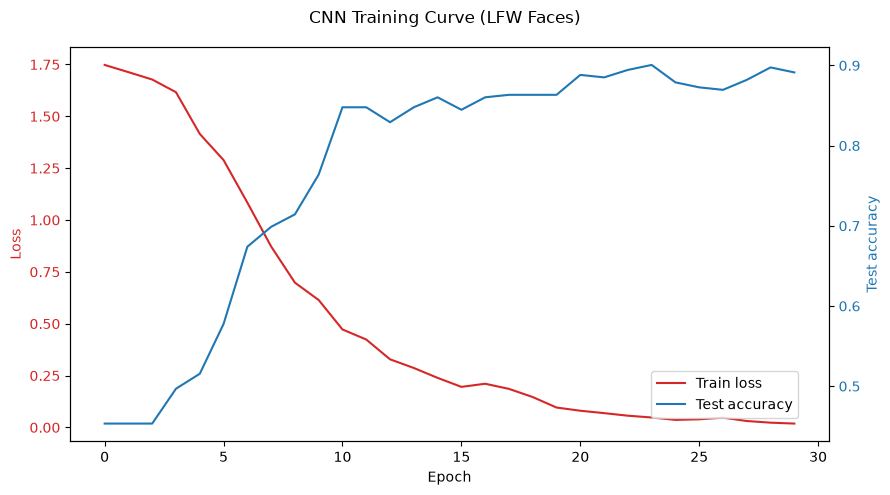

Saved: part3_1_training_curve.png


In [4]:
# ---------------------------------------------------------------------------
# DIAGRAM 1 - Training curve (loss + accuracy)
# ---------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(train_losses, color='tab:red', label='Train loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
 
ax2 = ax1.twinx()
ax2.plot(test_accs, color='tab:blue', label='Test accuracy')
ax2.set_ylabel('Test accuracy', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
 
fig.suptitle('CNN Training Curve (LFW Faces)')
fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.15))
plt.tight_layout()
plt.savefig('part3_1_training_curve.png', dpi=150)
plt.show()
print("Saved: part3_1_training_curve.png")

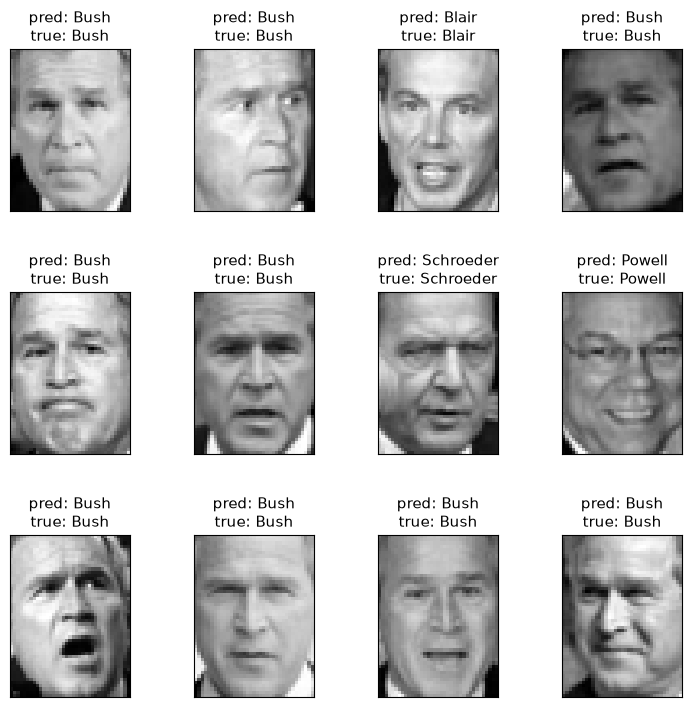

Saved: part3_1_predictions.png


In [5]:
# ---------------------------------------------------------------------------
# DIAGRAM 2 - Sample predictions gallery
# ---------------------------------------------------------------------------
model.eval()
with torch.no_grad():
    sample_preds = model(X_test_t[:12]).argmax(dim=1).cpu().numpy()
 
def title_prediction(y_pred, y_true, target_names, i):
    pred_name = target_names[y_pred[i]].rsplit(' ', 1)[-1]
    true_name = target_names[y_true[i]].rsplit(' ', 1)[-1]
    return f"pred: {pred_name}\ntrue: {true_name}"
 
fig = plt.figure(figsize=(1.8*4, 2.4*3))
plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.5)
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(X_test[i, 0], cmap=plt.cm.gray)
    plt.title(title_prediction(sample_preds, y_test, target_names, i), size=11)
    plt.xticks(())
    plt.yticks(())
plt.savefig('part3_1_predictions.png', dpi=150)
plt.show()
print("Saved: part3_1_predictions.png")

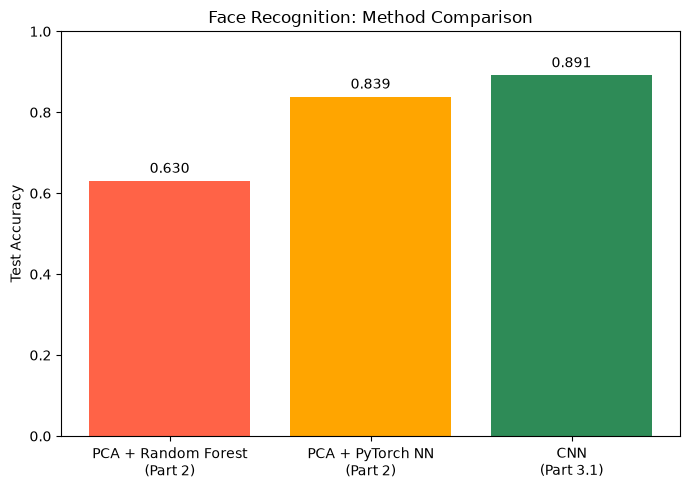

Saved: part3_1_method_comparison.png


In [ ]:
# ---------------------------------------------------------------------------
# DIAGRAM 3 - Comparison bar chart against Part 2 (fill in your actual Part 2 numbers)
# ---------------------------------------------------------------------------
part2_rf_accuracy = 0.6304
part2_pytorch_accuracy = 0.8385
 
plt.figure(figsize=(7, 5))
methods = ['PCA + Random Forest\n(Part 2)', 'PCA + PyTorch NN\n(Part 2)', 'CNN\n(Part 3.1)']
accs = [part2_rf_accuracy, part2_pytorch_accuracy, final_cnn_accuracy]
bars = plt.bar(methods, accs, color=['tomato', 'orange', 'seagreen'])
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.title('Face Recognition: Method Comparison')
for bar, val in zip(bars, accs):
    plt.text(bar.get_x()+bar.get_width()/2, val+0.02, f"{val:.3f}", ha='center')
plt.tight_layout()
plt.savefig('part3_1_method_comparison.png', dpi=150)
plt.show()
print("Saved: part3_1_method_comparison.png")